# Wafer Map Defect Signature Classification — Technical Summary

**John Conaghan** · follow-up to our conversation · full pipeline at the repo this notebook lives in

**What this is:** an ML pipeline that classifies the spatial failure signature on a wafer map (edge ring, scratch, center cluster, …) — the read an engineer does by eye at defect review, automated. Built end-to-end on a public dataset to demonstrate the approach without touching Intel data; everything here ran on my own hardware.

**Why it matters in a fab:** the spatial pattern of failing die is a fingerprint of root cause. Classifying it automatically on *every* wafer (not just the ones someone has time to review) means faster time-to-root-cause during excursions and reviewer hours back. The details of how — and the honest limitations — are below.

This notebook is the condensed version: dataset → inputs → models → results → interpretation. The full analysis is in notebooks `01`–`03`.

## 1. The dataset

**WM-811K (LSWMD)** — the standard public benchmark for this problem: **811,457 wafer maps from 46,293 production lots of a real fab**, released by MIR Lab (Wu, Jang & Chen, *IEEE Trans. Semiconductor Manufacturing*, 2015).

Key properties, all of which mirror real fab data:

- Only **~21% of maps carry an engineer-assigned failure label** (9 classes). The rest were never dispositioned — same as production, where most wafers never get reviewed.
- **Severe class imbalance**: ~85% of labeled wafers are "none" (no pattern). The rare classes are the actionable ones.
- **Mixed products**: die-grid dimensions vary wafer to wafer, so geometry normalization is part of the problem.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
from src import data

# preprocessed cache of the 172,950 labeled maps (see src/prepare_data.py)
X, y = data.load_labeled()
counts = pd.Series(y).value_counts().rename(index=dict(enumerate(data.CLASSES)))
summary = pd.DataFrame({"wafers": counts, "share": (counts / counts.sum()).round(4)})
print(f"labeled maps: {len(y):,} (of 811,457 total)\n")
summary

labeled maps: 172,950 (of 811,457 total)



,wafers,share
none,147431,0.8524
Edge-Ring,9680,0.0560
Edge-Loc,5189,0.0300
Center,4294,0.0248
Loc,3593,0.0208
Scratch,1193,0.0069
Random,866,0.0050
Donut,555,0.0032
Near-full,149,0.0009


## 2. The input — what the model actually sees

Each wafer map is a 2-D integer array over the die grid: **0 = outside wafer, 1 = passing die, 2 = failing die**. That's it — no parametric data, no images, just the sort/bin pass-fail map we already produce for every wafer.

Preprocessing is deliberately minimal:
1. Nearest-neighbour resample to a fixed **64×64** grid (products have different die counts; nearest-neighbour preserves the discrete encoding).
2. One-hot to 3 channels (outside / pass / fail) so the model treats them as categories, not intensities.

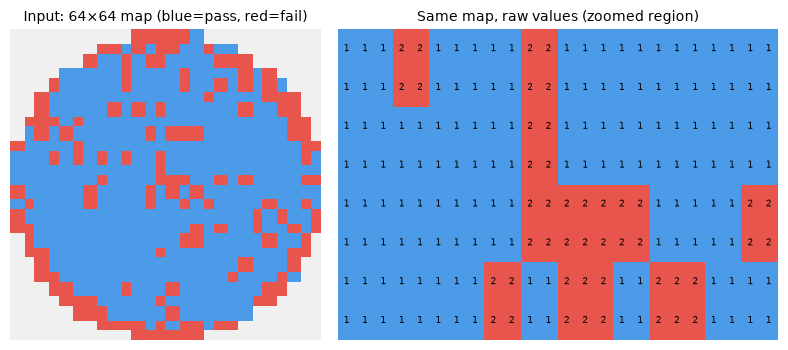

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

wafer_cmap = ListedColormap(["#f0f0f0", "#4c9be8", "#e8554c"])
example = X[np.flatnonzero(y == data.CLASSES.index("Edge-Ring"))[2]]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), gridspec_kw={"width_ratios": [1, 1.4]})
axes[0].imshow(example, cmap=wafer_cmap, vmin=0, vmax=2)
axes[0].set_title("Input: 64×64 map (blue=pass, red=fail)", fontsize=10)
axes[0].axis("off")
axes[1].imshow(example[26:34, 20:44], cmap=wafer_cmap, vmin=0, vmax=2, aspect="auto")
for (r, c), v in np.ndenumerate(example[26:34, 20:44]):
    axes[1].text(c, r, v, ha="center", va="center", fontsize=6.5)
axes[1].set_title("Same map, raw values (zoomed region)", fontsize=10)
axes[1].axis("off")
plt.tight_layout(); plt.show()

### The nine signatures, and why each one is actionable

| Signature | What it looks like | Points toward |
|---|---|---|
| Edge-Ring | fail band at wafer edge | chamber uniformity, edge processes, clamp/chuck contact |
| Edge-Loc | asymmetric edge cluster | single-side edge process issue |
| Center | fail cluster at center | center non-uniformity (dispense, etch-rate delta) |
| Donut | ring between center and edge | radial process non-uniformity |
| Scratch | thin line/arc | wafer handling / transfer damage |
| Loc | small local cluster | particle event, single-point contact |
| Random | scattered, no structure | baseline defectivity, no single assignable cause |
| Near-full | most of wafer failing | gross failure — wrong recipe, skipped step |
| none | clean | healthy baseline (85% of traffic) |

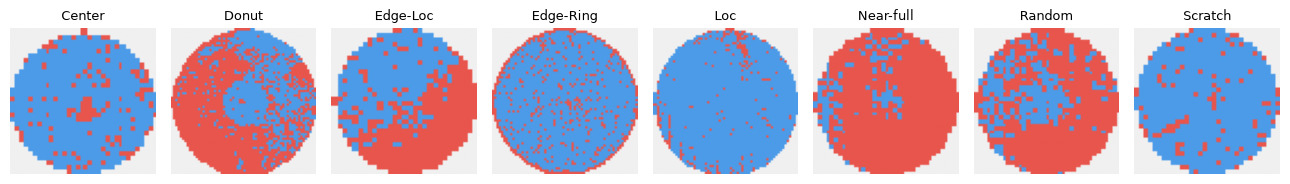

In [3]:
show = [c for c in data.CLASSES if c != "none"]
fig, axes = plt.subplots(1, 8, figsize=(13, 2))
rng = np.random.default_rng(3)
for ax, cls in zip(axes, show):
    idx = np.flatnonzero(y == data.CLASSES.index(cls))
    ax.imshow(X[rng.choice(idx)], cmap=wafer_cmap, vmin=0, vmax=2)
    ax.set_title(cls, fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 3. The models

Two approaches, compared deliberately — the point is to know when learned features earn their complexity.

**Baseline — 18 engineered features + gradient boosting** (`02_baseline.ipynb`). Each feature encodes something a defect engineer would name: fail density in 5 concentric rings (separates Center/Donut/Edge-Ring), quadrant densities (asymmetry), projection statistics at 20 angles (a scratch has one high-variance direction), and connected-component geometry (cluster count, dominance, elongation). Classifier: `HistGradientBoostingClassifier`, class-weighted. Fully interpretable — you can read the permutation importances in fab language.

**CNN — small convnet, class-balanced training** (`03_cnn.ipynb`). Three conv blocks (32→64→128 channels), global average pooling, ~300k parameters — sized to the problem, since the input is a 64×64 grid with 3 discrete values. Trained 15 epochs with a `WeightedRandomSampler` so each batch sees all classes roughly equally despite the 85/15 skew; without this the loss is dominated by "none" and rare classes never train.

In [4]:
import torch
from src.models import WaferCNN

model = WaferCNN(n_classes=len(data.CLASSES))
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}\n")
print(model)

parameters: 289,065

WaferCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

## 4. Results

Evaluation below is live: the trained CNN checkpoint is loaded and re-scored on the held-out test set — **34,590 wafers the model never saw during training**, at the true production class mix (85% clean).

In [5]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from src.models import WaferDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
# identical split to training (same seeds) -> identical held-out test set
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model.load_state_dict(torch.load("../models/wafer_cnn.pt", map_location=device, weights_only=True))
model = model.to(device).eval()

preds = []
with torch.no_grad():
    for xb, _ in DataLoader(WaferDataset(X_te, y_te), batch_size=512):
        preds.append(model(xb.to(device)).argmax(1).cpu())
pred = torch.cat(preds).numpy()

print(f"test wafers: {len(y_te):,}  |  device: {device}\n")
print(classification_report(y_te, pred, target_names=data.CLASSES, digits=3))

test wafers: 34,590  |  device: cuda

              precision    recall  f1-score   support

      Center      0.859     0.874     0.867       859
       Donut      0.825     0.766     0.794       111
    Edge-Loc      0.761     0.849     0.803      1038
   Edge-Ring      0.967     0.977     0.972      1936
         Loc      0.677     0.682     0.680       718
   Near-full      0.794     0.900     0.844        30
      Random      0.836     0.855     0.846       173
     Scratch      0.743     0.653     0.695       239
        none      0.989     0.985     0.987     29486

    accuracy                          0.967     34590
   macro avg      0.828     0.838     0.832     34590
weighted avg      0.968     0.967     0.968     34590



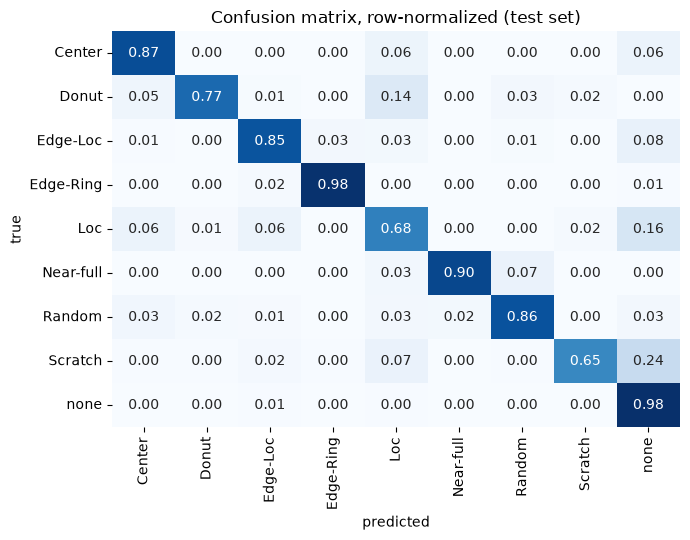

In [6]:
import seaborn as sns
cm = confusion_matrix(y_te, pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=data.CLASSES, yticklabels=data.CLASSES, ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix, row-normalized (test set)")
plt.tight_layout(); plt.show()

### Interpretation — what these numbers actually mean

**The number that matters most is "none" precision: 0.989.** At production ratios (~85% of traffic is clean), false-alarm rate decides whether an auto-classifier is a tool or a nuisance. This model flags fewer than 1 clean wafer in 90 — the engineered-feature baseline flagged ~3× more. That's the difference between an alarm engineers trust and one they filter to a folder.

**Geometric signatures are essentially solved.** Edge-Ring at 0.97 F1, Center at 0.87 — the patterns with clear radial structure classify reliably. These are also the highest-value signatures for excursion response (chamber uniformity, center non-uniformity).

**The hard residue is small and diffuse.** Loc (~0.68 F1) and Scratch recall (0.65) are the weak spots — small ambiguous clusters and faint thin scratches at 64×64 resolution. Notably the *baseline struggles on exactly the same classes*, which says the difficulty lives in the data (genuinely ambiguous wafers, single-label constraint), not the model choice. The error gallery in `03_cnn.ipynb` shows many "misclassifications" are wafers a human would also hesitate on.

**Baseline vs CNN, honestly:** macro-F1 is ~equal (0.84 vs 0.83) — but the CNN was tested on the much harder full production mix and wins decisively on false-alarm suppression and scratch precision (0.51 → 0.74). The engineered features remain competitive on clean geometric classes and are more explainable. A production system could legitimately use both: features for cheap triage, CNN for confirmation.

## 5. How this maps to our fab

The input here — a per-die pass/fail map — is exactly the shape of data in WCS inline defect and sort systems. An internal version would be the same pipeline pointed at that data, running on approved internal infrastructure (nothing in this demo touched Intel systems or data).

Deployment pattern that makes operational sense:

1. **Classify every map** as it lands (inference is milliseconds per wafer on CPU).
2. **High-confidence signatures auto-tag** → SPC trending per signature per tool, excursion alarms on signature-rate shifts (e.g. an Edge-Ring rate step on one chamber is an actionable, specific alarm).
3. **Low-confidence maps queue for engineer review** — the model abstains rather than guesses; the review queue shrinks to the genuinely ambiguous cases.

The win is measured in **reviewer hours returned and time-to-root-cause during excursions**, not accuracy points. The realistic gaps for an internal pilot: a labeling campaign on our own signature taxonomy (WM-811K's 9 classes won't map 1:1), multi-label support (real wafers carry overlapping signatures), and drift monitoring as products change.

---

*Dataset: Wu, Jang & Chen, "Wafer Map Failure Pattern Recognition and Similarity Ranking for Large-Scale Data Sets," IEEE Trans. Semiconductor Manufacturing 28(1), 2015. Reproduce: `README.md` at repo root — one script prepares the data, notebooks `01`–`03` are the full analysis.*